# Task 5
* 对家用热水器数据进行探索分析
* 对家用热水器数据进行预处理
* 使用梯度提升树进行建模

In [86]:
import os
import sys
import numpy as np
import pandas as pd
from loguru import logger
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from tqdm import tqdm, trange
import graphviz
import scienceplots
plt.style.use(['nature', 'vibrant']) # 或者 'ieee', 'nature'
from matplotlib import font_manager

font_path="/home/lanshi/.local/share/fonts/SourceHanSerifSC-Regular.otf"
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False


logger.remove()

logger.add(
    sink=sys.stderr,
    level="INFO",
    format="<green>{time:YYYY-MM-DD HH:mm:ss.SSS}</green> | "
            "<level>{level:<8}</level> | "
            "<cyan>{name}</cyan>:<cyan>{function}</cyan>:<cyan>{line}</cyan> - "
            "<level>{message}</level>",
    colorize=True
)
logger.info(plt.rcParams['font.family'])

2026-07-11 22:13:56.970 | INFO     | __main__:<module>:35 - ['Source Han Serif SC']


## 对家用热水器数据进行探索分析

In [80]:
raw_data=pd.read_excel("./data/raw/water_heater.xls")
raw_data.head()

,发生时间,开关机状态,加热中,保温中,实际温度,热水量,水流量,加热剩余时间,当前设置温度
0,20141019063917,关,关,关,30°C,0%,0,0分钟,50°C
1,20141019070154,关,关,关,30°C,0%,0,0分钟,50°C
2,20141019070156,关,关,关,30°C,0%,8,0分钟,50°C
3,20141019071230,关,关,关,30°C,0%,0,0分钟,50°C
4,20141019071236,关,关,关,29°C,0%,0,0分钟,50°C


In [81]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 18840 entries, 0 to 18839
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   发生时间    18840 non-null  int64
 1   开关机状态   18840 non-null  str  
 2   加热中     18840 non-null  str  
 3   保温中     18840 non-null  str  
 4   实际温度    18840 non-null  str  
 5   热水量     18840 non-null  str  
 6   水流量     18840 non-null  int64
 7   加热剩余时间  18840 non-null  str  
 8   当前设置温度  18840 non-null  str  
dtypes: int64(2), str(7)
memory usage: 1.3 MB


## 对家用热水器数据进行预处理

In [82]:
raw_data["开关机状态"] = raw_data["开关机状态"].map({"关": 0, "开": 1}).astype("float32")
raw_data["加热中"]=raw_data["加热中"].map({"关": 0, "开": 1}).astype("float32")
raw_data["保温中"]=raw_data["保温中"].map({"关": 0, "开": 1}).astype("float32")
raw_data.rename(columns={"实际温度":"实际温度/°C"},inplace=True)
raw_data["实际温度/°C"]=raw_data["实际温度/°C"].str.replace(
    "°C",
    "",
    regex=False
).astype("float32")
raw_data.rename(columns={"热水量":"热水量/%"},inplace=True)
raw_data["热水量/%"]=raw_data["热水量/%"].str.replace(
    "%",
    "",
    regex=False
).astype("float32")
raw_data.rename(columns={"加热剩余时间":"加热剩余时间/min"},inplace=True)
raw_data["加热剩余时间/min"]=raw_data["加热剩余时间/min"].str.replace(
    "分钟",
    "",
    regex=False
).astype("float32")
raw_data.rename(columns={"当前设置温度":"当前设置温度/°C"},inplace=True)
raw_data["当前设置温度/°C"]=raw_data["当前设置温度/°C"].str.replace(
    "°C",
    "",
    regex=False
).astype("float32")
raw_data["水流量"]=raw_data["水流量"].astype("float32")
raw_data["发生时间"]=raw_data["发生时间"].astype(str)
raw_data['发生时间'] = pd.to_datetime(raw_data[u'发生时间'], format = '%Y%m%d%H%M%S')


In [83]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 18840 entries, 0 to 18839
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   发生时间        18840 non-null  datetime64[us]
 1   开关机状态       18840 non-null  float32       
 2   加热中         18840 non-null  float32       
 3   保温中         18840 non-null  float32       
 4   实际温度/°C     18840 non-null  float32       
 5   热水量/%       18840 non-null  float32       
 6   水流量         18840 non-null  float32       
 7   加热剩余时间/min  18840 non-null  float32       
 8   当前设置温度/°C   18840 non-null  float32       
dtypes: datetime64[us](1), float32(8)
memory usage: 736.1 KB


In [84]:
raw_data.describe()

,发生时间,开关机状态,加热中,保温中,实际温度/°C,热水量/%,水流量,加热剩余时间/min,当前设置温度/°C
count,18840,18840.000000,18840.000000,18840.000000,18840.000000,18840.000000,18840.000000,18840.000000,18840.0
mean,2014-10-30 03:03:07.757802,0.416295,0.306263,0.110032,39.408493,22.656582,12.870594,3.491189,50.0
min,2014-10-19 06:39:17,0.000000,0.000000,0.000000,28.000000,0.000000,0.000000,0.000000,50.0
25%,2014-10-24 14:38:04.500000,0.000000,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,50.0
50%,2014-10-29 21:38:39.500000,0.000000,0.000000,0.000000,39.000000,25.000000,0.000000,0.000000,50.0
75%,2014-11-05 15:06:59,1.000000,1.000000,0.000000,47.000000,50.000000,26.000000,2.000000,50.0
max,2014-11-10 23:20:00,1.000000,1.000000,1.000000,51.000000,100.000000,77.000000,31.000000,50.0
std,NaN,0.492957,0.460953,0.312938,7.634646,21.724987,17.122814,6.983866,0.0


In [85]:
X=raw_data.drop(columns="加热剩余时间/min")
y=raw_data["加热剩余时间/min"]

## 使用梯度提升树进行建模

In [ ]:
# 目标：用 GradientBoostingClassifier 预测“是否在淋浴”
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

data = raw_data.copy()

# 1) 构造/确定标签列
required_cols = ["水流量", "开关机状态"]
data["是否在淋浴"] = ((data["水流量"] > 0) & (data["开关机状态"] == 1)).astype(int)
target_col = "是否在淋浴"

# 标签转成 0/1
if data[target_col].dtype == "object":
    y = LabelEncoder().fit_transform(data[target_col].astype(str))
else:
    y = data[target_col].astype(int).values

# 2) 构造特征
X = data.drop(columns=[target_col]).copy()

# datetime 列转时间戳
for col in X.columns:
    if np.issubdtype(X[col].dtype, np.datetime64):
        X[col] = X[col].astype("int64") // 10**9

# object 类别特征做 one-hot
obj_cols = X.select_dtypes(include=["object", "category"]).columns
if len(obj_cols) > 0:
    X = pd.get_dummies(X, columns=list(obj_cols), drop_first=True)

# 缺失值填充，防止模型报错
X = X.fillna(X.median(numeric_only=True)).fillna(0)

# 3) 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4) 训练模型
gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train, y_train)

# 5) 预测与评估
y_pred = gb_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 二分类时给出 AUC
if len(np.unique(y_test)) == 2:
    y_prob = gb_clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC: {auc:.4f}")

# 供后续单元使用
feature_names = X.columns

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2947
           1       1.00      1.00      1.00       821

    accuracy                           1.00      3768
   macro avg       1.00      1.00      1.00      3768
weighted avg       1.00      1.00      1.00      3768

Confusion Matrix:
[[2947    0]
 [   0  821]]
ROC-AUC: 1.0000


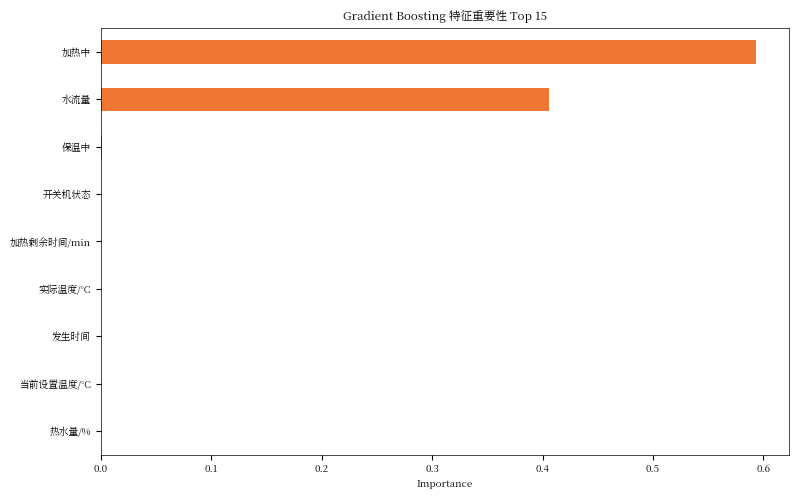

,y_true,y_pred
0,1,1
1,1,1
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


In [89]:
# 可视化特征重要性（前 15 个）
import matplotlib.pyplot as plt

importances = pd.Series(gb_clf.feature_importances_, index=feature_names).sort_values(ascending=False)
top_k = min(15, len(importances))

plt.figure(figsize=(8, 5))
importances.head(top_k).sort_values().plot(kind="barh")
plt.title("Gradient Boosting 特征重要性 Top 15")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 查看一部分预测结果
result_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred
})
result_df.head(10)